In [99]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import sys
from pathlib import Path

# add repo root so swiss_roll_models can be imported from anywhere
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "swiss_roll_models").exists():
        sys.path.insert(0, str(p))
        break

from environment.hilbert_distance import hilbert_analysis as hda



# ============================
# 1. Define a simple MNIST model
# ============================

class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 10)  # We mainly track the weights of this layer

    def forward(self, x):
        # x: (B, 1, 28, 28)
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        logits = self.fc2(x)
        return logits






In [100]:
# ============================
# 2.  Training + Hilbert Distance Tracking
# ============================

from xml.parsers.expat import model


def train_mnist_with_hilbert(
    num_epochs=3,
    batch_size=128,
    lr=1e-2,
    device=None,
    if_regularize=True,
    if_decay=False,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # ---- Random seed (for reproducibility) ----
    torch.manual_seed(42)

    # ---- MNIST data ----
    transform = transforms.Compose([
        transforms.ToTensor(),                  # [0, 1]
        transforms.Normalize((0.1307,), (0.3081,)),
    ])

    train_dataset = datasets.MNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    # ---- Model, loss, optimizer ----
    model = MNISTNet().to(device)
    criterion = nn.CrossEntropyLoss()
    if if_regularize:
        if if_decay:
            optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=1e-4)
        else:
            optimizer = torch.optim.SGD(
                [
                    {"params": model.fc1.parameters(), "weight_decay": 0},
                    {"params": model.fc2.parameters(), "weight_decay": 1e-4},
                ],
                lr=lr
            )
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
        
    # ---- Used to store parameter trajectory (for Hilbert analysis) ----
    # We only track the last layer fc2.weight
    param_traj = []

    def get_positive_flat_last_layer():
        """
        Extract the last layer weights from the model -> flatten -> map to positive cone (abs + eps)
        """
        with torch.no_grad():
            w = model.fc2.weight.detach().clone().view(-1)
            w_pos = w.abs() + 1e-6  # Strictly positive to avoid hilbert_distance errors
        return w_pos

    # Record initial point
    param_traj.append(get_positive_flat_last_layer())

    # =======================
    # Training loop
    # =======================
    global_step = 0
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            # Track training accuracy (optional)
            running_loss += loss.item() * images.size(0)
            _, predicted = logits.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            # After each parameter update, record the positive cone weights of the last layer
            param_traj.append(get_positive_flat_last_layer())
            global_step += 1

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}]  "
              f"Loss: {epoch_loss:.4f}  Acc: {epoch_acc*100:.2f}%")

    print(f"Training finished. Total recorded steps (including init): {len(param_traj)}")

    # =======================
    # 3. Hilbert Distance Analysis
    # =======================
    # Here we directly take the final weights as w_star
    w_star = param_traj[-1]

    # No masking, no secondary thresholding (because we have already done abs+eps)
    hilbert_result = hda.analysis_distance_on_cone(
        param_traj=param_traj,
        w_star=w_star,
        threshold=None,
        ifmask=False,
        if_threshold=False,
        if_self_adaptive=False,
    )

    hilbert_to_final = hilbert_result["hilbert_to_final"]
    hilbert_to_init = hilbert_result["hilbert_to_init"]
    hilbert_between = hilbert_result["hilbert_between"]

    print("\n=== Hilbert Analysis Results (Partial) ===")
    print(f"len(hilbert_to_final)  = {len(hilbert_to_final)}  # Distance to w* at each step")
    print(f"len(hilbert_to_init)   = {len(hilbert_to_init)}   # Distance to w0 at each step")
    print(f"len(hilbert_between)   = {len(hilbert_between)}  # Distance between consecutive steps")

    print("\nFirst 10 steps d_H(w_t, w*):")
    print([float(x) for x in hilbert_to_final[:10]])

    print("\nFirst 10 steps d_H(w_t, w_0):")
    print([float(x) for x in hilbert_to_init[:10]])

    print("\nFirst 10 steps d_H(w_t, w_{t-1}):")
    print([float(x) for x in hilbert_between[:10]])

    # You can also return additional results here for later plotting / ratio analysis
    return {
        "model": model,
        "param_traj": param_traj,
        "hilbert_result": hilbert_result,
        "hilbert_to_final": hilbert_to_final,
        "hilbert_to_init": hilbert_to_init,
        "hilbert_between": hilbert_between,
    }


In [101]:

num_epochs = 3
batch_size = 512
lr = 1e-2
if_regularize = True
if_decay = False
# batch_size = {16,32,64,128,256}
result=train_mnist_with_hilbert(
    num_epochs=num_epochs,
    batch_size=batch_size,
    lr=lr,
    if_regularize=if_regularize,
    if_decay=if_decay,
)


Using device: cuda
Epoch [1/3]  Loss: 1.4363  Acc: 68.04%
Epoch [2/3]  Loss: 0.6744  Acc: 84.75%
Epoch [3/3]  Loss: 0.5009  Acc: 87.40%
Training finished. Total recorded steps (including init): 355

=== Hilbert Analysis Results (Partial) ===
len(hilbert_to_final)  = 355  # Distance to w* at each step
len(hilbert_to_init)   = 355   # Distance to w0 at each step
len(hilbert_between)   = 354  # Distance between consecutive steps

First 10 steps d_H(w_t, w*):
[14.332449913024902, 14.3158540725708, 13.612386703491211, 13.387798309326172, 14.301349639892578, 13.468860626220703, 14.211132049560547, 14.049505233764648, 15.72571086883545, 13.707839965820312]

First 10 steps d_H(w_t, w_0):
[0.0, 2.329819679260254, 2.9308180809020996, 3.852591037750244, 5.500053882598877, 5.5877532958984375, 6.873884677886963, 6.021720886230469, 9.29981803894043, 8.250961303710938]

First 10 steps d_H(w_t, w_{t-1}):
[2.329819679260254, 1.2143511772155762, 0.9217731952667236, 2.4552016258239746, 2.635450839996338,

In [102]:
hilbert_to_final=result["hilbert_to_final"]
hilbert_to_init=result["hilbert_to_init"]
hilbert_between=result["hilbert_between"]


In [103]:
print("\n=== Hilbert Analysis (Partial) No Masking ===")
print('Parameters: num_epochs={}, batch_size={}, lr={}'.format(num_epochs, batch_size, lr))
print(f"len(hilbert_to_final)  = {len(hilbert_to_final)}  # Distance to w* at each step")
print(f"len(hilbert_to_init)   = {len(hilbert_to_init)}   # Distance to w0 at each step")
print(f"len(hilbert_between)   = {len(hilbert_between)}  # Distance between consecutive steps")

print("\nFirst 10 steps d_H(w_t, w*):")
print([float(x) for x in hilbert_to_final[:10]])

print("\nFirst 10 steps d_H(w_t, w_0):")
print([float(x) for x in hilbert_to_init[:10]])

print("\nFirst 10 steps d_H(w_t, w_{t-1}):")
print([float(x) for x in hilbert_between[:10]])

# ============================
# Extra: Contraction Ratios (Geometric Contractivity)
# ============================
ratios_to_final = []
for t in range(len(hilbert_to_final) - 1):
    if hilbert_to_final[t] > 0:
        ratios_to_final.append(hilbert_to_final[t+1] / hilbert_to_final[t])
    else:
        ratios_to_final.append(float("nan"))

ratios_between = []
for t in range(len(hilbert_between) - 1):
    if hilbert_between[t] > 0:
        ratios_between.append(hilbert_between[t+1] / hilbert_between[t])
    else:
        ratios_between.append(float("nan"))

print("\nFirst 20 ratios: d_H(w_{t+1}, w*) / d_H(w_t, w*):")
print(ratios_to_final[:20])

# Simple statistics: remove the initial volatile steps
burn_in = 20
if len(ratios_to_final) > burn_in + 10:
    tail = ratios_to_final[burn_in:]
    tail_clean = [r for r in tail if not math.isnan(r) and r != float("inf")]
    if len(tail_clean) > 0:
        print(f"\nFrom step>{burn_in} onwards, ratio_to_final:")
        print(f"  Mean ≈ {sum(tail_clean)/len(tail_clean):.4f}")
        print(f"  Min ≈ {min(tail_clean):.4f}, Max ≈ {max(tail_clean):.4f}")


=== Hilbert Analysis (Partial) No Masking ===
Parameters: num_epochs=3, batch_size=512, lr=0.01
len(hilbert_to_final)  = 355  # Distance to w* at each step
len(hilbert_to_init)   = 355   # Distance to w0 at each step
len(hilbert_between)   = 354  # Distance between consecutive steps

First 10 steps d_H(w_t, w*):
[14.332449913024902, 14.3158540725708, 13.612386703491211, 13.387798309326172, 14.301349639892578, 13.468860626220703, 14.211132049560547, 14.049505233764648, 15.72571086883545, 13.707839965820312]

First 10 steps d_H(w_t, w_0):
[0.0, 2.329819679260254, 2.9308180809020996, 3.852591037750244, 5.500053882598877, 5.5877532958984375, 6.873884677886963, 6.021720886230469, 9.29981803894043, 8.250961303710938]

First 10 steps d_H(w_t, w_{t-1}):
[2.329819679260254, 1.2143511772155762, 0.9217731952667236, 2.4552016258239746, 2.635450839996338, 2.6776487827301025, 2.9079041481018066, 3.969543218612671, 6.949014663696289, 4.0734357833862305]

First 20 ratios: d_H(w_{t+1}, w*) / d_H(w_t, 


 The last 200 steps' ratio_to_final:
  Mean ≈ 0.9973
  Min ≈ 0.0000, Max ≈ 2.0203

The 200 to 1200: ratio_to_final:
  Mean ≈ 0.9958
  Min ≈ 0.0000, Max ≈ 2.0203


<Figure size 640x480 with 0 Axes>

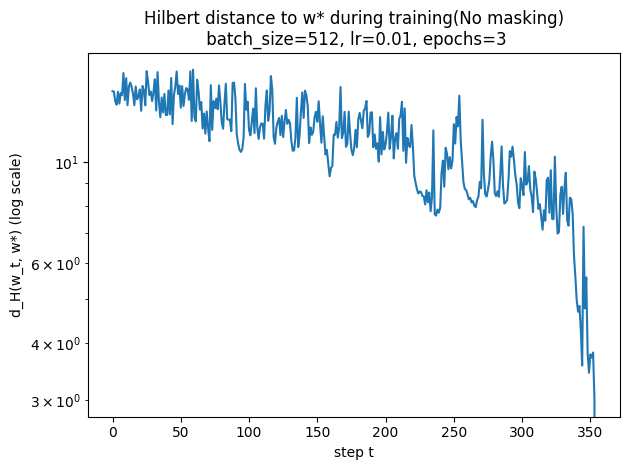

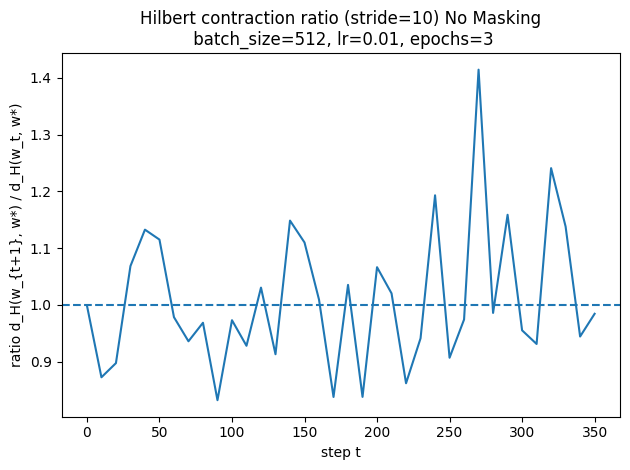

In [104]:
if sys.path and "swiss_roll_models" in sys.path[0]:
    sys.path.pop(0)

%matplotlib inline
import matplotlib.pyplot as plt
plt.figure()
# ============================
# Plot: Hilbert Distance and Contraction Ratios
# ============================
steps = list(range(len(hilbert_to_final)))

plt.figure()
plt.semilogy(steps, hilbert_to_final)
plt.xlabel("step t")
plt.ylabel("d_H(w_t, w*) (log scale)")
plt.title(f"Hilbert distance to w* during training(No masking)\n batch_size={batch_size}, lr={lr}, epochs={num_epochs}")
plt.tight_layout()
plt.savefig("hilbert_to_final.png")

# To avoid overcrowding, downsample a bit before plotting ratio
stride = 10
ratio_idx = list(range(0, len(ratios_to_final), stride))
ratio_vals = [ratios_to_final[i] for i in ratio_idx]

plt.figure()
plt.plot(ratio_idx, ratio_vals)
plt.xlabel("step t")
plt.ylabel("ratio d_H(w_{t+1}, w*) / d_H(w_t, w*)")
plt.axhline(1.0, linestyle="--")
plt.title(f"Hilbert contraction ratio (stride={stride}) No Masking\n batch_size={batch_size}, lr={lr}, epochs={num_epochs}")
plt.tight_layout()
plt.savefig("hilbert_ratio_to_final.png")


print("\n The last 200 steps' ratio_to_final:")
tail_200 = ratios_to_final[-200:]
tail_200_clean = [r for r in tail_200 if not math.isnan(r)]
if len(tail_200_clean) > 0:
    print(f"  Mean ≈ {sum(tail_200_clean)/len(tail_200_clean):.4f}")
    print(f"  Min ≈ {min(tail_200_clean):.4f}, Max ≈ {max(tail_200_clean):.4f}")
medium_1000 = ratios_to_final[200:1200]
medium_1000_clean = [r for r in medium_1000 if not math.isnan(r)]
if len(medium_1000_clean) > 0:
    print(f"\nThe 200 to 1200: ratio_to_final:")
    print(f"  Mean ≈ {sum(medium_1000_clean)/len(medium_1000_clean):.4f}")
    print(f"  Min ≈ {min(medium_1000_clean):.4f}, Max ≈ {max(medium_1000_clean):.4f}")


In [105]:
!pip install matplotlib

In [106]:
para_traj2 = result["param_traj"]   # The original positive trajectory (already abs+1e-6 processed)
w_star_raw = para_traj2[-1].clone()

# The support threshold you want
thr = 1.1e-3
eps0 = 1e-6   # Should be >= the eps used in hilbert_distance (yours seems to be 1e-10, so no problem)

# Use w* to define the support of the small positive cone: only keep dimensions where |w*| > thr
mask = (w_star_raw.abs() > thr)

masked_traj2 = []
for v in para_traj2:
    v_abs = v.clone().abs()
    # Inside the support: keep the original size (add eps0 to ensure strictly positive)
    # Outside the support: set directly to eps0 (constant, does not participate in Hilbert geometry)
    v_smallcone = torch.where(
        mask,
        v_abs + eps0,
        torch.full_like(v_abs, eps0)
    )
    masked_traj2.append(v_smallcone)

# Similarly process w_star (which is actually the last element of masked_traj2)
w_star_smallcone = masked_traj2[-1]

# Note: Now param_traj is a sequence of strictly positive vectors in the "small positive cone + background pinned to eps0"
# Completely disable internal mask / threshold logic
hilbert_result2 = hda.analysis_distance_on_cone(
    param_traj=masked_traj2,
    w_star=w_star_smallcone,  # Not matter but do pass it
    threshold=None,           # No internal threshold logic since we have already done masking externally
    ifmask=False,             # Key: disable internal mask_by_wstar_support
    if_threshold=False,       # Key: disable internal automatic eps clamp
    if_self_adaptive=False,
)
hilbert_to_final2 = hilbert_result2["hilbert_to_final"]
hilbert_between2 = hilbert_result2["hilbert_between"]
hilbert_to_init2 = hilbert_result2["hilbert_to_init"]


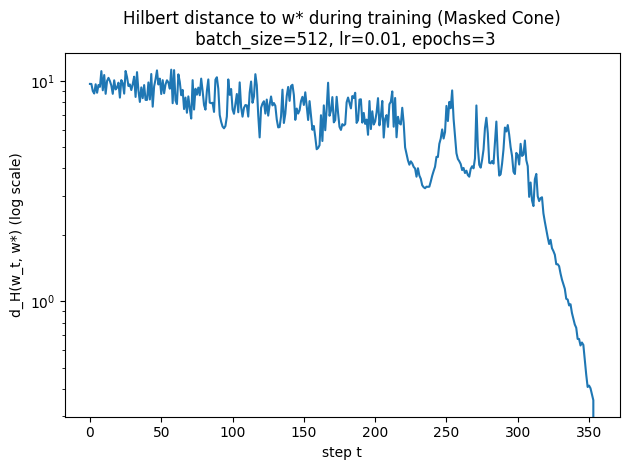

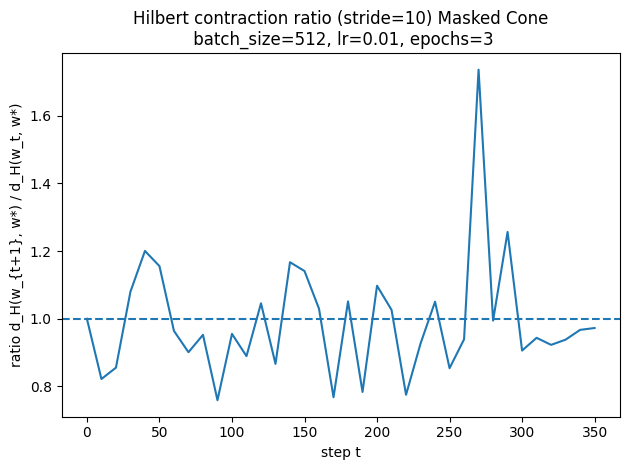

In [ ]:
ratios_to_final2 = []
for t in range(len(hilbert_to_final2) - 1):
    if hilbert_to_final2[t] > 0:
        ratios_to_final2.append(hilbert_to_final2[t+1] / hilbert_to_final2[t])
    else:
        ratios_to_final2.append(float("nan"))

ratios_between2 = []
for t in range(len(hilbert_between2) - 1):
    if hilbert_between2[t] > 0:
        ratios_between2.append(hilbert_between2[t+1] / hilbert_between2[t])
    else:
        ratios_between.append(float("nan"))


steps = list(range(len(hilbert_to_final2)))

print("\Last 200 Steps ratio_to_final：")
tail_200 = ratios_to_final2[-200:]
tail_200_clean2 = [r for r in tail_200 if not math.isnan(r)]
if len(tail_200_clean2) > 0:
    print(f"  Mean ≈ {sum(tail_200_clean2)/len(tail_200_clean2):.4f}")
    print(f"  Min ≈ {min(tail_200_clean2):.4f}, Max ≈ {max(tail_200_clean2):.4f}")
medium_1000 = ratios_to_final2[200:1200]
medium_1000_clean = [r for r in medium_1000 if not math.isnan(r)]
if len(medium_1000_clean) > 0:
    print(f"\nRatio_to_final from step 200 to 1200:")
    print(f"  Mean ≈ {sum(medium_1000_clean)/len(medium_1000_clean):.4f}")
    print(f"  Min ≈ {min(medium_1000_clean):.4f}, Max ≈ {max(medium_1000_clean):.4f}")
    
plt.figure()
plt.semilogy(steps, hilbert_to_final2)
plt.xlabel("step t")
plt.ylabel("d_H(w_t, w*) (log scale)")
plt.title("Hilbert distance to w* during training (Masked Cone)\n batch_size={}, lr={}, epochs={}".format(batch_size, lr, num_epochs))
plt.tight_layout()
plt.savefig("hilbert_to_final2.png")

# Sampling ratio
stride = 10
ratio_idx2 = list(range(0, len(ratios_to_final2), stride))
ratio_vals2 = [ratios_to_final2[i] for i in ratio_idx2]

plt.figure()
plt.plot(ratio_idx2, ratio_vals2)
plt.xlabel("step t")
plt.ylabel("ratio d_H(w_{t+1}, w*) / d_H(w_t, w*)")
plt.axhline(1.0, linestyle="--")
plt.title(f"Hilbert contraction ratio (stride={stride}) Masked Cone\n batch_size={batch_size}, lr={lr}, epochs={num_epochs}")
plt.tight_layout()
plt.savefig("hilbert_ratio_to_final2.png")

In [109]:
import ipynbname
import os
import subprocess
import zipfile

def export_as_zip(num_epoch, lr, batchsize, if_decay, execute=False):
    # ---- Notebook name ----
    nb_base = ipynbname.name()
    nb_file = nb_base + ".ipynb"

    # ---- Construct output base name (no extension!) ----
    param_str = f"_ep{num_epoch}_lr{lr}_bs{batchsize}_decay{if_decay}"
    tex_base = nb_base + param_str   # 例如 MNIST_Classification_ep3_lr0.01_bs128_decayFalse

    # ---- Unique base name to avoid overwrite ----
    def unique_root(name):
        candidate = name
        i = 1
        # 只要发现同名 .tex 或 .zip，就换一个根
        while os.path.exists(candidate + ".tex") or os.path.exists(candidate + ".zip"):
            candidate = f"{name}_{i}"
            i += 1
        return candidate

    tex_root = unique_root(tex_base)      # 不带 .tex
    tex_file = tex_root + ".tex"          # 真正的 .tex 文件名
    files_dir = tex_root + "_files"       # 图片所在文件夹
    zip_name = tex_root + ".zip"          # 打包结果

    # ---- Convert using nbconvert ----
    command = [
        "jupyter", "nbconvert",
        "--to", "latex",
        "--output", tex_root,  # ⭐ 注意：这里用的是 root，不带 .tex
    ]
    if execute:
        command.append("--execute")
    command.append(nb_file)

    print("Running:", " ".join(command))
    subprocess.run(command)

    # ---- Create ZIP ----
    if not os.path.exists(tex_file):
        print(f"⚠ 找不到导出的 tex 文件: {tex_file}")
        return None

    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as z:
        # Add .tex file
        z.write(tex_file)

        # Add folder with images
        if os.path.exists(files_dir):
            for root, dirs, files in os.walk(files_dir):
                for f in files:
                    full_path = os.path.join(root, f)
                    arcname = os.path.relpath(full_path, ".")
                    z.write(full_path, arcname)

    print(f"\n✨ Exported to ZIP: {zip_name}\n")
    return zip_name


In [ ]:
export_as_zip(
    num_epoch=num_epochs,
    batchsize=batch_size,
    if_decay=if_decay,
    lr=lr,
    execute=True  # ★ 是否重新执行整个 notebook
)
# close file


Running: jupyter nbconvert --to latex --output MNIST_Classification_ep3_lr0.01_bs512_decayFalse --execute MNIST_Classification.ipynb

✨ Exported to ZIP: MNIST_Classification_ep3_lr0.01_bs512_decayFalse.zip



'MNIST_Classification_ep3_lr0.01_bs512_decayFalse.zip'